1. Dataset processing and data augmentation
2. Convoultion  networks
3. ReLU pooling and LRN
4. Fully connected layers
5. Dropout
6. SGD with momentum and weight decay
7. Training and validation


In [27]:
#using imagenet dataset using pytorch 
from pathlib import Path 
DATA_DIR = Path("datasets")/"tiny-imagenet-200" 

from torchvision import datasets,transforms 
from torch.utils.data import DataLoader 
import torch 

In [28]:
#applying transforms to training and validation sets 

train_transforms = transforms.Compose([
    transforms.RandomCrop(64,padding=4), 
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.4802, 0.4481, 0.3975],
        std=[0.2302, 0.2265, 0.2262]
    ), 
])

val_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(
        mean=[0.4802, 0.4481, 0.3975],
        std=[0.2302, 0.2265, 0.2262]
    )
]) 




In [29]:
train_dataset = datasets.ImageFolder( 
    root = DATA_DIR / "train", 
    transform = train_transforms
) 
print("# of training dataset img : ",len(train_dataset))
print("Number of classes : ", len(train_dataset.classes))

# of training dataset img :  100000
Number of classes :  200


In [30]:
import shutil

#Reorganize the validation images
val_dir = Path.home() /"Desktop" / "mlnb" / "cs231n" / "datasets" / "tiny-imagenet-200" / "val"
images_dir = val_dir / "images"
annotations_file = val_dir / "val_annotations.txt"

with open(annotations_file, "r") as file:
    for line in file:
        parts = line.strip().split("\t")

        image_name = parts[0]
        class_name = parts[1]

        class_dir = val_dir / class_name
        class_dir.mkdir(exist_ok=True)

        source = images_dir / image_name
        destination = class_dir / image_name

        if source.exists() and not destination.exists():
            shutil.move(str(source), str(destination))

if images_dir.exists() and not any(images_dir.iterdir()):
    images_dir.rmdir()



In [31]:
val_dataset = datasets.ImageFolder(
    root = DATA_DIR / "val",
    transform = val_transforms
)

print("# of training dataset img : ",len(val_dataset))
print("Number of classes : ", len(val_dataset.classes))

# of training dataset img :  10000
Number of classes :  200


In [32]:
batch_size = 128 

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
    
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
    
)

In [33]:
#device 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [34]:
images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Pixel range:", images.min().item(), images.max().item())

Image batch: torch.Size([128, 3, 64, 64])
Label batch: torch.Size([128])
Pixel range: -2.086012125015259 2.663571834564209


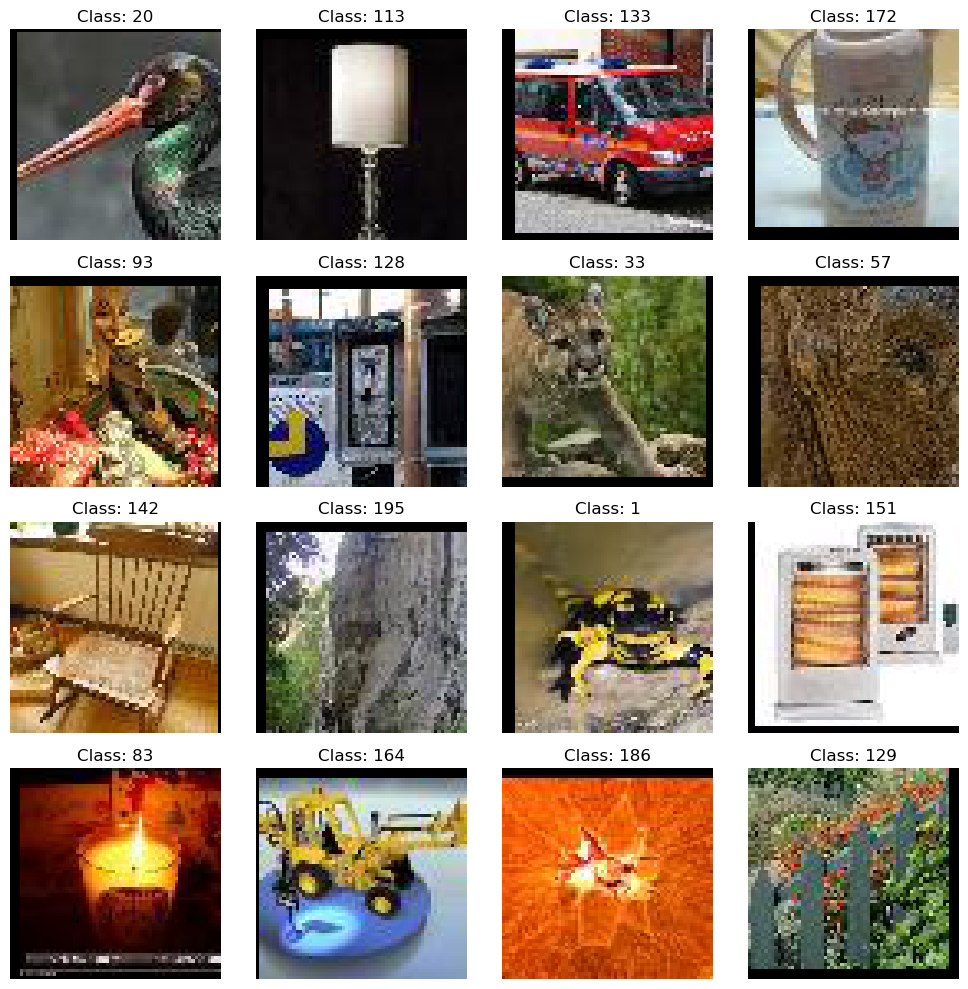

In [42]:
import matplotlib.pyplot as plt
import torch

mean = torch.tensor([0.4802, 0.4481, 0.3975]).view(3, 1, 1)
std = torch.tensor([0.2302, 0.2265, 0.2262]).view(3, 1, 1)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10)
)

for i in range(16):
    image = images[i].cpu()

    # Reverse normalization
    image = image * std + mean

    # Convert [C, H, W] -> [H, W, C]
    image = image.permute(1, 2, 0)

    axis = axes.flat[i]

    axis.imshow(image.clamp(0, 1))
    axis.set_title(f"Class: {labels[i].item()}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [44]:
import torch
from torch import nn


class TinyAlexNet(nn.Module):
    """
    AlexNet-inspired CNN adapted for Tiny ImageNet.

    Channel progression:
    3 -> 32 -> 64 -> 128 -> 128 -> 128

    Uses:
    - ReLU for non-linearity
    - Local Response Normalization after the first two convolutions
    - Overlapping max pooling: kernel_size=3, stride=2
    - Dropout to reduce overfitting and neuron co-adaptation
    """

    def __init__(self, num_classes=200):
        super().__init__()

        self.features = nn.Sequential(
            # Input: [B, 3, 64, 64]

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=5,
                stride=1,
                padding=2
            ),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(
                size=5,
                alpha=1e-4,
                beta=0.75,
                k=2
            ),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # [B, 32, 31, 31]

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                stride=1,
                padding=2
            ),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(
                size=5,
                alpha=1e-4,
                beta=0.75,
                k=2
            ),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # [B, 64, 15, 15]

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            # [B, 128, 15, 15]

            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=3, stride=2)
            # [B, 128, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)

        # [B, 128, 7, 7] -> [B, 6272]
        x = torch.flatten(x, start_dim=1)

        # Returns raw logits of shape [B, 200]
        x = self.classifier(x)

        return x